In [1]:
pip install mysql-connector-python sqlalchemy pymysql pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sqlalchemy import create_engine
import mysql.connector
from urllib.parse import quote_plus 
print("Libraries loaded!")

Libraries loaded!


In [3]:
user     = "root"
password = quote_plus("NewPassword123")  
host     = "localhost"
database = "climate"

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}/{database}")

print("Connected to MySQL successfully!")

Connected to MySQL successfully!


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\weather\Indian_Climate_Dataset_2024_2025.csv")
df = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\weather\india_2000_2024_daily_weather (1).csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91320 entries, 0 to 91319
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   city                         91320 non-null  object 
 1   date                         91320 non-null  object 
 2   temperature_2m_max           91320 non-null  float64
 3   temperature_2m_min           91320 non-null  float64
 4   apparent_temperature_max     91320 non-null  float64
 5   apparent_temperature_min     91320 non-null  float64
 6   precipitation_sum            91320 non-null  float64
 7   rain_sum                     91320 non-null  float64
 8   weather_code                 91320 non-null  int64  
 9   wind_speed_10m_max           91320 non-null  float64
 10  wind_gusts_10m_max           91320 non-null  float64
 11  wind_direction_10m_dominant  91320 non-null  int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 8.4+ MB


In [5]:
df['date'] = pd.to_datetime(df['date'])
df.dtypes

city                                   object
date                           datetime64[ns]
temperature_2m_max                    float64
temperature_2m_min                    float64
apparent_temperature_max              float64
apparent_temperature_min              float64
precipitation_sum                     float64
rain_sum                              float64
weather_code                            int64
wind_speed_10m_max                    float64
wind_gusts_10m_max                    float64
wind_direction_10m_dominant             int64
dtype: object

In [6]:
df.duplicated().sum()
df = df.drop_duplicates()

df = df.sort_values(by=['city', 'date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

df['temperature_2m_max'].describe()
df['precipitation_sum'].describe()

count    91320.000000
mean         3.092751
std          9.164448
min          0.000000
25%          0.000000
50%          0.000000
75%          1.700000
max        339.900000
Name: precipitation_sum, dtype: float64

In [7]:
df.rename(columns={
    'temperature_2m_max': 'temp_max',
    'temperature_2m_min': 'temp_min'
}, inplace=True)
df.columns

Index(['city', 'date', 'temp_max', 'temp_min', 'apparent_temperature_max',
       'apparent_temperature_min', 'precipitation_sum', 'rain_sum',
       'weather_code', 'wind_speed_10m_max', 'wind_gusts_10m_max',
       'wind_direction_10m_dominant', 'year', 'month', 'day'],
      dtype='object')

In [8]:
df['temp_range'] = df['temp_max'] - df['temp_min']
df[['temp_max', 'temp_min', 'temp_range']].head()

,temp_max,temp_min,temp_range
54792,29.9,15.3,14.6
54793,29.9,16.1,13.8
54794,29.1,15.1,14.0
54795,28.6,13.7,14.9
54796,28.1,13.2,14.9


In [35]:
df.groupby('city')['temp_max'].mean().sort_values(ascending=False)

KeyError: 'Column not found: temp_max'

In [34]:
import pandas as pd

df = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\weather\Indian_Climate_Dataset_2024_2025.csv")
df = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\weather\india_2000_2024_daily_weather (1).csv")

print("Dataset 1 Columns:")
print(df.columns)

print("\nDataset 2 Columns:")
print(df.columns)

Dataset 1 Columns:
Index(['city', 'date', 'temperature_2m_max', 'temperature_2m_min',
       'apparent_temperature_max', 'apparent_temperature_min',
       'precipitation_sum', 'rain_sum', 'weather_code', 'wind_speed_10m_max',
       'wind_gusts_10m_max', 'wind_direction_10m_dominant'],
      dtype='object')

Dataset 2 Columns:
Index(['city', 'date', 'temperature_2m_max', 'temperature_2m_min',
       'apparent_temperature_max', 'apparent_temperature_min',
       'precipitation_sum', 'rain_sum', 'weather_code', 'wind_speed_10m_max',
       'wind_gusts_10m_max', 'wind_direction_10m_dominant'],
      dtype='object')


In [10]:
!pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd

df_temp = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\weather\Indian_Climate_Dataset_2024_2025.csv")
df_rain = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\weather\india_2000_2024_daily_weather (1).csv")

In [14]:
print(df_temp.columns)
print(df_rain.columns)

Index(['Date', 'City', 'State', 'Temperature_Max (°C)', 'Temperature_Min (°C)',
       'Temperature_Avg (°C)', 'Humidity (%)', 'Rainfall (mm)',
       'Wind_Speed (km/h)', 'AQI', 'AQI_Category', 'Pressure (hPa)',
       'Cloud_Cover (%)'],
      dtype='object')
Index(['city', 'date', 'temperature_2m_max', 'temperature_2m_min',
       'apparent_temperature_max', 'apparent_temperature_min',
       'precipitation_sum', 'rain_sum', 'weather_code', 'wind_speed_10m_max',
       'wind_gusts_10m_max', 'wind_direction_10m_dominant'],
      dtype='object')


In [15]:
df_temp.rename(columns={
    'Temperature_Avg (°C)': 'Temperature',
    'Rainfall (mm)': 'Rainfall'
}, inplace=True)

In [16]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df_temp['Temperature'], df_temp['Rainfall'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.021346340679526427
P-value: 0.06800454038399623


In [17]:
from scipy.stats import pearsonr
df_temp['Year'] = pd.to_datetime(df_temp['Date']).dt.year
corr, p_value = pearsonr(df_temp['Year'], df_temp['Temperature'])
print(corr, p_value)

0.008676249675121104 0.45827289937216403


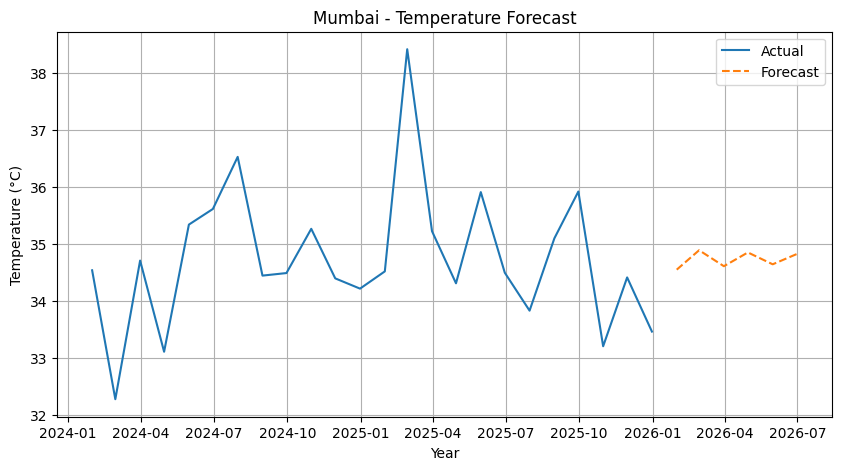

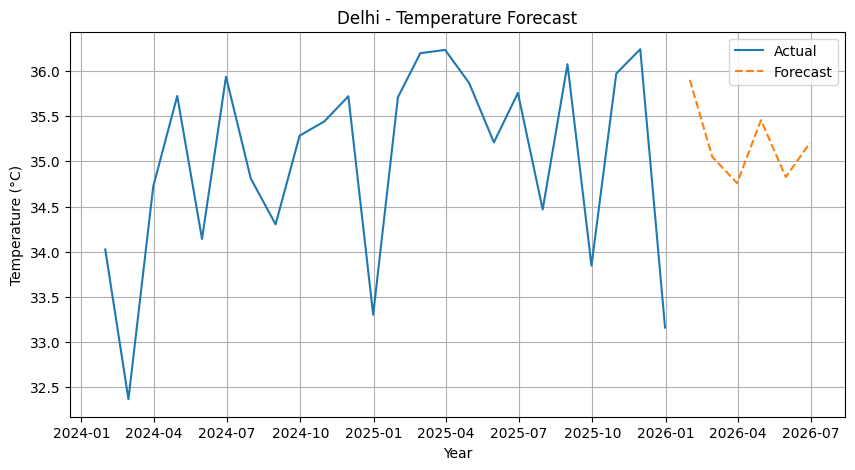

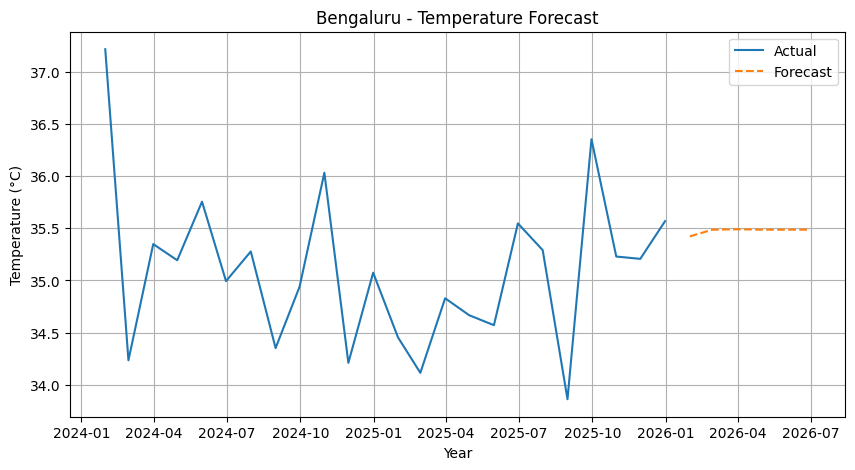

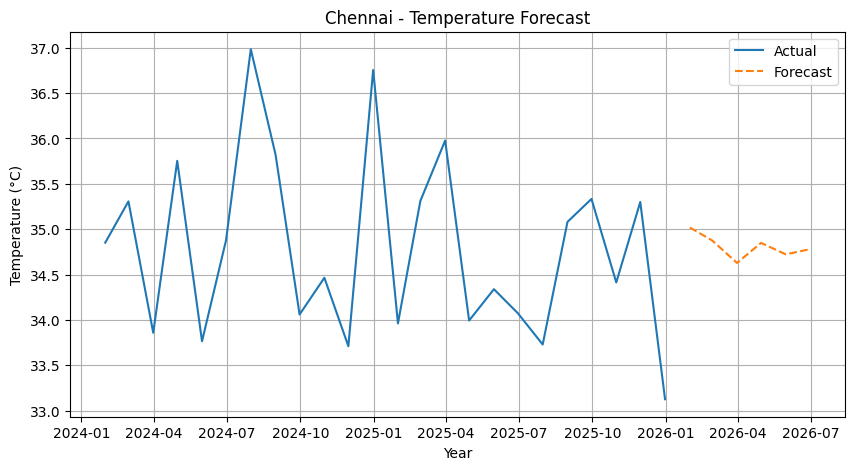

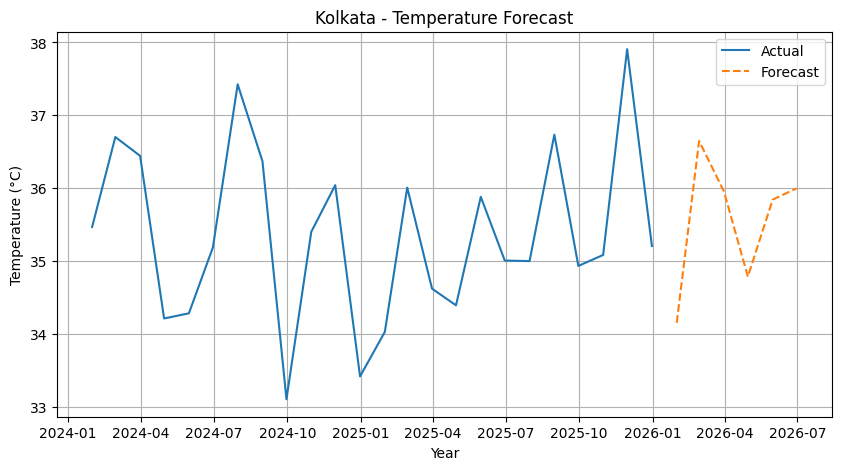

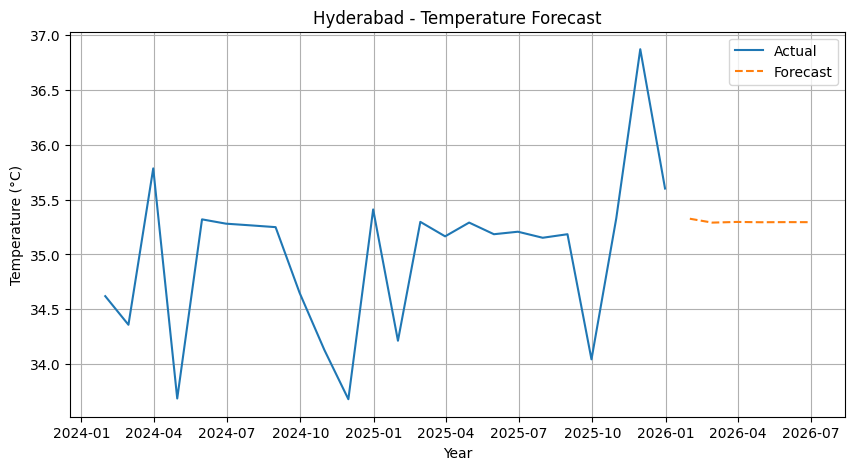

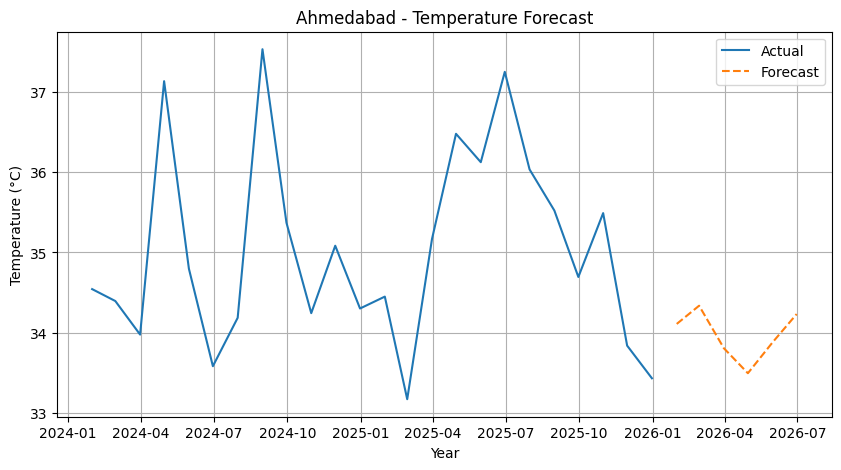

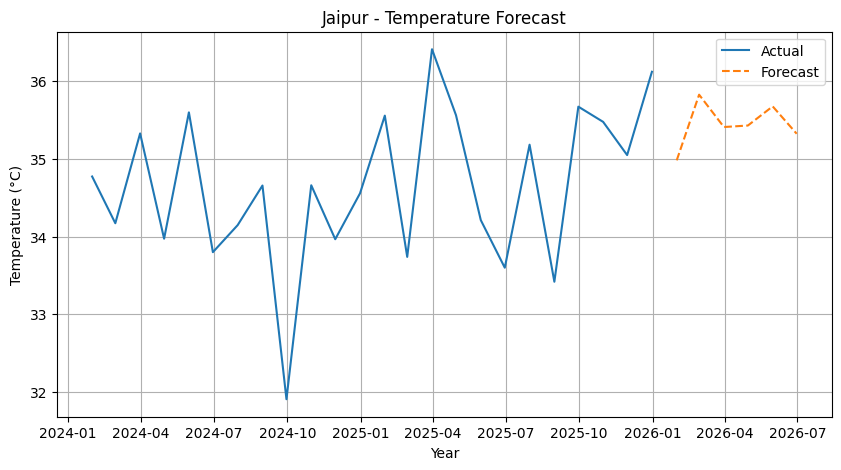

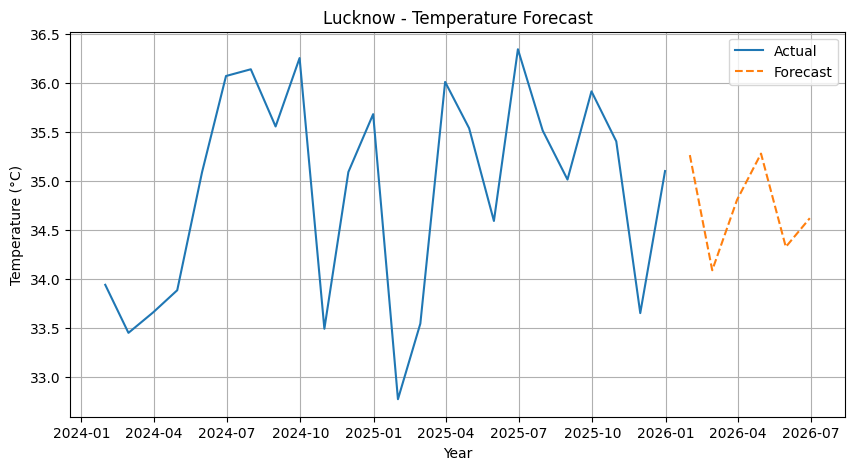

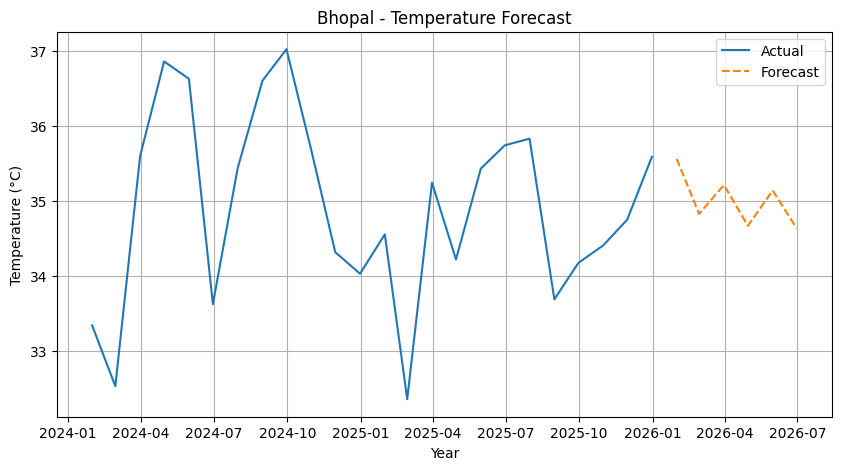

In [18]:
#Temperature Trends & Forecast Across Indian Cities
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\weather\indian_climate_dataset_2024_2025.csv")

# =========================
# 2. CLEAN DATA
# =========================
df.columns = df.columns.str.strip().str.lower()
df['date'] = pd.to_datetime(df['date'])

# Find temperature column
temp_col = [col for col in df.columns if 'temp' in col and 'max' in col][0]

# Get all cities
cities = df['city'].dropna().unique()

# =========================
# 3. LOOP THROUGH CITIES
# =========================
for city in cities:

    df_city = df[df['city'] == city].copy()

    if len(df_city) < 30:
        continue

    df_city = df_city.sort_values('date')
    df_city.set_index('date', inplace=True)

    # Smooth data (monthly)
    ts = df_city[temp_col].resample('M').mean()

    try:
        # Model
        model = ARIMA(ts, order=(2,1,2))
        model_fit = model.fit()

        # Forecast
        forecast = model_fit.forecast(steps=6)

        # =========================
        # 4. PLOT
        # =========================
        plt.figure(figsize=(10,5))

        plt.plot(ts, label="Actual")
        plt.plot(forecast, linestyle='--', label="Forecast")

        plt.title(f"{city} - Temperature Forecast")
        plt.xlabel("Year")
        plt.ylabel("Temperature (°C)")
        plt.legend()
        plt.grid(True)

        plt.show()

    except:
        print(f"Skipping {city}")

Anomalous Years:
year
2002    8074.5
Name: rain_sum, dtype: float64


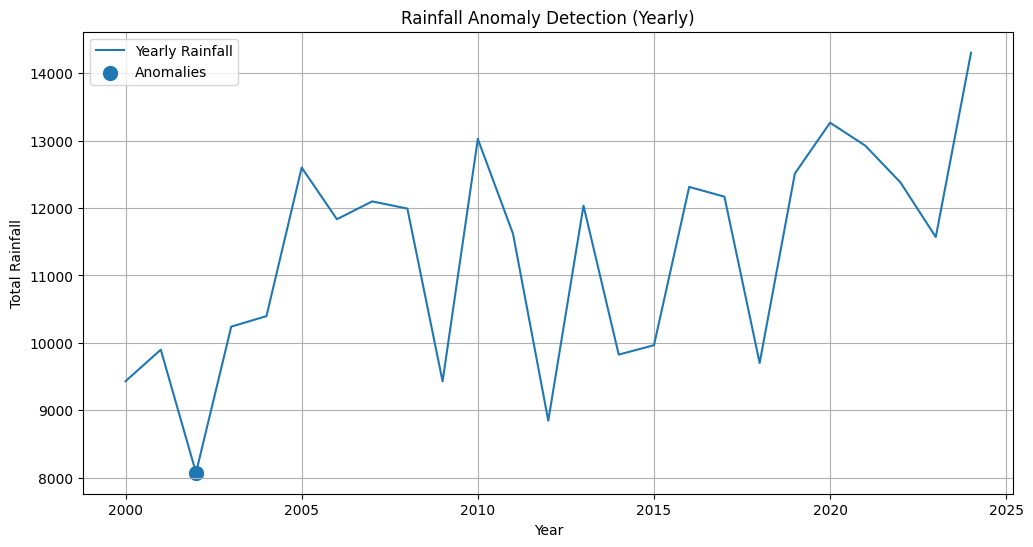

In [19]:
#2 Rainfall Anomaly Detection
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\weather\india_2000_2024_daily_weather (1).csv")

# =========================
# 2. CLEAN DATA
# =========================
df.columns = df.columns.str.strip().str.lower()
df['date'] = pd.to_datetime(df['date'])

# Extract year
df['year'] = df['date'].dt.year

# =========================
# 3. SELECT RAINFALL COLUMN
# =========================
# Adjust if column name differs
rain_col = [col for col in df.columns if 'rain' in col][0]

# =========================
# 4. YEARLY RAINFALL
# =========================
yearly_rain = df.groupby('year')[rain_col].sum()

# =========================
# 5. Z-SCORE (ANOMALY DETECTION)
# =========================
mean = yearly_rain.mean()
std = yearly_rain.std()

z_scores = (yearly_rain - mean) / std

# Mark anomalies
anomalies = yearly_rain[(z_scores > 2) | (z_scores < -2)]

print("Anomalous Years:")
print(anomalies)

# =========================
# 6. VISUALIZATION
# =========================
plt.figure(figsize=(12,6))

# Normal years
plt.plot(yearly_rain, label="Yearly Rainfall")

# Highlight anomalies
plt.scatter(anomalies.index, anomalies.values, label="Anomalies", s=100)

plt.title("Rainfall Anomaly Detection (Yearly)")
plt.xlabel("Year")
plt.ylabel("Total Rainfall")
plt.legend()
plt.grid(True)

plt.show()

           temperature_avg (°c)  humidity (%)  rainfall (mm)  cluster
city                                                                 
Ahmedabad             30.144323     63.664432       8.457729        2
Bengaluru             30.080027     62.256772       7.456498        0
Bhopal                29.964569     63.471819       8.258824        2
Chennai               29.831327     61.818878       7.894938        0
Delhi                 30.074282     62.620383       8.277839        2
Hyderabad             29.978386     62.379207       8.704104        2
Jaipur                29.645691     62.307114       8.527633        0
Kolkata               30.412722     63.457319       8.378659        1
Lucknow               29.899316     61.888646       8.255540        0
Mumbai                29.771272     62.670588       8.101231        0


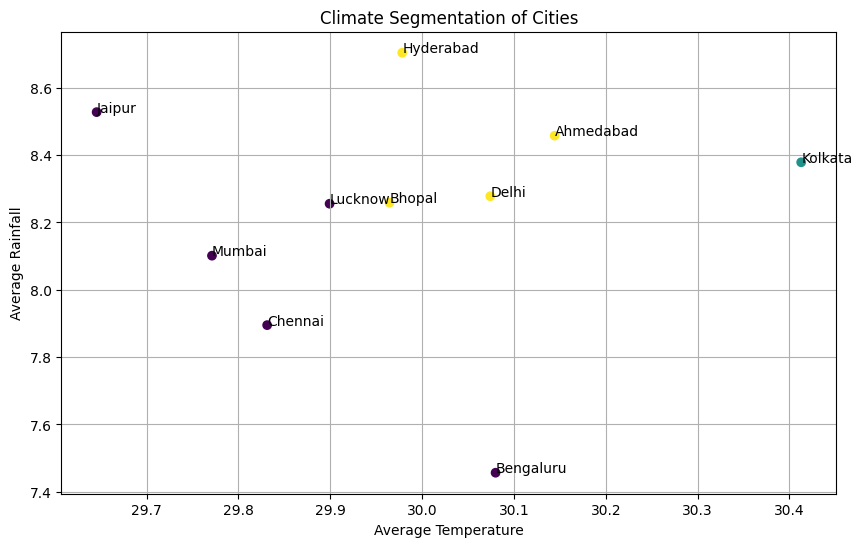

In [20]:
#3 Climate Segmentation of Indian Cities
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\weather\indian_climate_dataset_2024_2025.csv")

# =========================
# 2. CLEAN DATA
# =========================
df.columns = df.columns.str.strip().str.lower()

# =========================
# 3. SELECT FEATURES
# =========================
# Adjust column names if needed
temp_col = [col for col in df.columns if 'temp' in col and 'avg' in col][0]
humidity_col = [col for col in df.columns if 'humidity' in col][0]
rain_col = [col for col in df.columns if 'rain' in col][0]

# =========================
# 4. GROUP BY CITY (average climate)
# =========================
city_data = df.groupby('city')[[temp_col, humidity_col, rain_col]].mean()

# =========================
# 5. SCALE DATA
# =========================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(city_data)

# =========================
# 6. APPLY K-MEANS
# =========================
kmeans = KMeans(n_clusters=3, random_state=42)
city_data['cluster'] = kmeans.fit_predict(scaled_data)

print(city_data)

# =========================
# 7. VISUALIZATION
# =========================
plt.figure(figsize=(10,6))

plt.scatter(city_data[temp_col], city_data[rain_col], c=city_data['cluster'])

for i, city in enumerate(city_data.index):
    plt.text(city_data[temp_col][i], city_data[rain_col][i], city)

plt.title("Climate Segmentation of Cities")
plt.xlabel("Average Temperature")
plt.ylabel("Average Rainfall")

plt.grid(True)
plt.show()

weather_type
Normal     4748
Extreme    2562
Name: count, dtype: int64


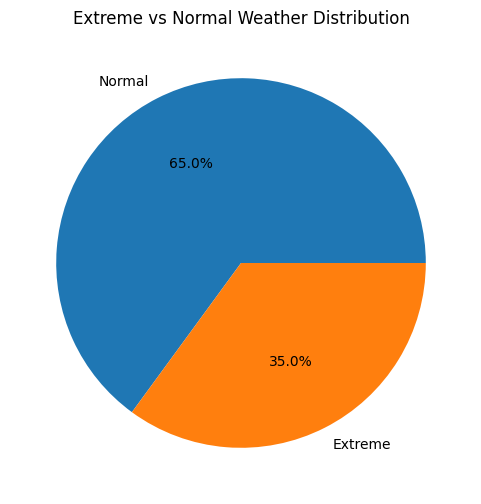

In [21]:
#4 Extreme Weather Distribution
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\weather\indian_climate_dataset_2024_2025.csv")

# =========================
# 2. CLEAN DATA
# =========================
df.columns = df.columns.str.strip().str.lower()
df['date'] = pd.to_datetime(df['date'])

# =========================
# 3. IDENTIFY COLUMNS
# =========================
temp_col = [col for col in df.columns if 'temp' in col and 'max' in col][0]
humidity_col = [col for col in df.columns if 'humidity' in col][0]
rain_col = [col for col in df.columns if 'rain' in col][0]
wind_col = [col for col in df.columns if 'wind' in col][0]

# =========================
# 4. DEFINE EXTREME RULES
# =========================
def classify_weather(row):
    if (row[temp_col] > 40) or \
       (row[rain_col] > 50) or \
       (row[humidity_col] > 90) or \
       (row[wind_col] > 50):
        return "Extreme"
    else:
        return "Normal"

df['weather_type'] = df.apply(classify_weather, axis=1)

# =========================
# 5. SUMMARY
# =========================
print(df['weather_type'].value_counts())

# =========================
# 6. VISUALIZATION
# =========================
counts = df['weather_type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Extreme vs Normal Weather Distribution")
plt.show()

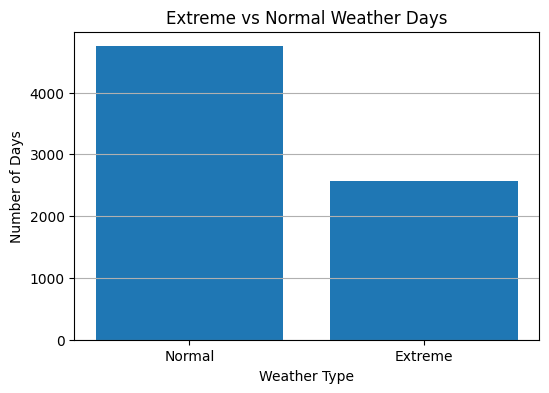

In [22]:
counts = df['weather_type'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("Extreme vs Normal Weather Days")
plt.xlabel("Weather Type")
plt.ylabel("Number of Days")
plt.grid(axis='y')

plt.show()

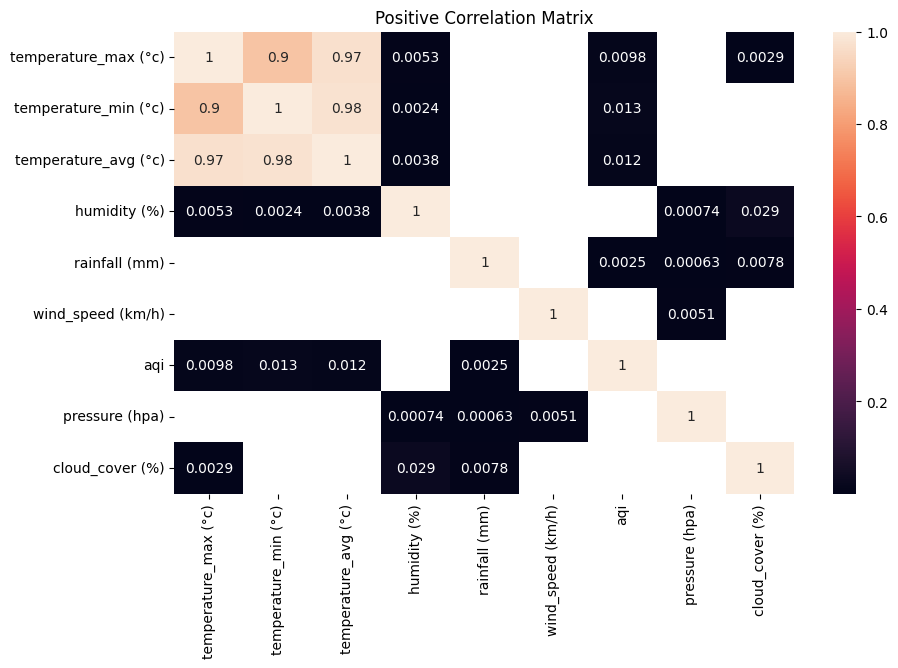

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

# Keep only positive values
corr_positive = corr[corr > 0]

plt.figure(figsize=(10,6))
sns.heatmap(corr_positive, annot=True)
plt.title("Positive Correlation Matrix")
plt.show()

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\weather\india_2000_2024_daily_weather (1).csv")

df['weather_type'] = df.apply(
    lambda x: 'Extreme' if (x['temperature_2m_max'] > 35 or x['rain_sum'] > 100) else 'Normal',
    axis=1
)

print(df.head())

    city        date  temperature_2m_max  temperature_2m_min  \
0  Delhi  2000-01-01                19.9                 7.4   
1  Delhi  2000-01-02                20.0                 5.5   
2  Delhi  2000-01-03                20.1                 6.3   
3  Delhi  2000-01-04                19.8                 6.4   
4  Delhi  2000-01-05                19.4                 5.3   

   apparent_temperature_max  apparent_temperature_min  precipitation_sum  \
0                      19.2                       5.8                0.0   
1                      18.9                       3.4                0.0   
2                      18.2                       4.3                0.0   
3                      18.5                       4.2                0.0   
4                      17.7                       3.2                0.0   

   rain_sum  weather_code  wind_speed_10m_max  wind_gusts_10m_max  \
0       0.0             0                10.9                13.3   
1       0.0         

In [28]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
extreme_per_year = df[df['weather_type'] == 'Extreme'].groupby('year').size()
total_days = df.groupby('year').size()
extreme_percentage = (extreme_per_year / total_days) * 100

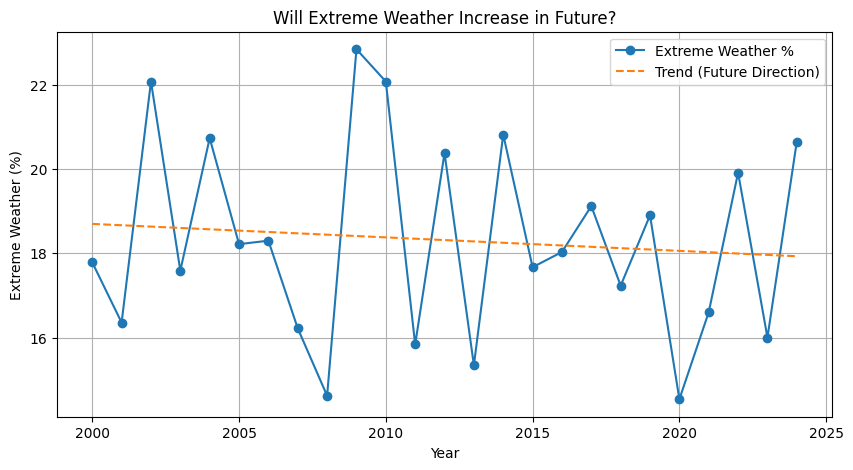

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

# Actual trend
plt.plot(extreme_percentage.index, extreme_percentage.values, 
         marker='o', label='Extreme Weather %')

# Trend line (future idea)
x = extreme_percentage.index
y = extreme_percentage.values

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.plot(x, p(x), linestyle='--', label='Trend (Future Direction)')

plt.title("Will Extreme Weather Increase in Future?")
plt.xlabel("Year")
plt.ylabel("Extreme Weather (%)")
plt.legend()
plt.grid()
plt.show()

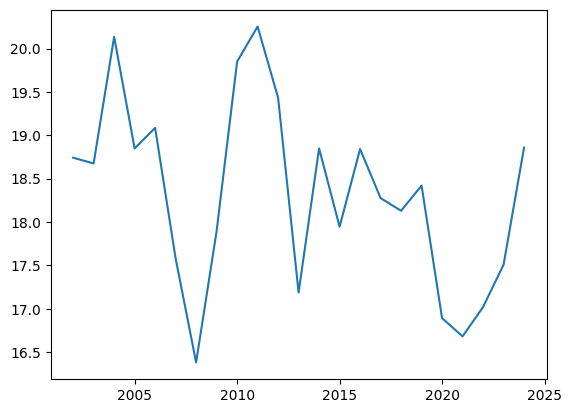

In [31]:
smoothed = extreme_percentage.rolling(3).mean()

plt.plot(smoothed.index, smoothed.values, label='Smoothed Trend')